# Appendix — supplementary / robustness analyses

This notebook runs the five standalone reporting scripts that back the
supplementary figures and the reviewer-facing robustness checks. They are *not*
part of the main `01`–`07` pipeline; they re-use the persisted joint coordinates
(`joint_umap_*_xy.tsv`) and the shipped tables, so **no UMAP /
BERTopic re-run is needed** — but notebook `03` must have produced the
coordinates, and notebook `06` the `overlap_precedence_full.tsv` that §3 and §5
read.

| § | Script | What it answers | Outputs (run folder `assets/<date>/05/`) |
|---|--------|-----------------|------------------------------|
| 1 | `density_eras.py` | **R2** — is the teams-vs-papers spatial division of labour stable across eras (2004–2014 vs 2015–2025)? | `density_ratio_eras.png` |
| 2 | `geography_lq.py` | Geographic specialization of the outsider community via Location Quotient | `geography_location_quotient.tsv`, `geography_lq.png` |
| 3 | `geography_topic_matrix.py` | Do outsider-tilted countries concentrate in the iGEM-led topics? (ties geography → precedence) | `geography_topic_matrix.tsv`, `geography_topic_matrix.png`, `geography_lead_orientation.png` |
| 4 | `geography_outsiderness.py` | Do countries *stop* being outsiders over time? | `geography_outsiderness_teams.tsv`, `geography_outsiderness_trajectory.tsv`, `geography_outsiderness_trajectory.png`, `geography_outsiderness_field_check.png` |
| 5 | `precedence_robustness.py` | **R1** — does the precedence result survive changes in year statistic and neighbourhood parameters? | `precedence_robustness.tsv`, `precedence_robustness_sensitivity.tsv`, `precedence_robustness.png` |

> **Order matters:** §3 and §4 read the `geography_location_quotient.tsv` that §2
> writes, so run the cells top to bottom.

## Setup

Run each script from this notebook's directory (`05-reporting/`) so that `%run`
resolves the scripts. Each script calls `setup_run.setup()`, which copies any missing
inputs into today's run folder (`assets/<date>/05/`) and writes its outputs there.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Locate 05-reporting robustly whether the kernel started here or at the repo root.
_candidates = [Path.cwd(), Path.cwd() / "05-reporting"]
REPORTING = next((p for p in _candidates if (p / "density_eras.py").exists()), None)
assert REPORTING is not None, f"Could not locate 05-reporting from {Path.cwd()}"
os.chdir(REPORTING)
import sys
sys.path.insert(0, str(REPORTING))
from setup_run import setup

RUN = setup()          # today's run folder: assets/<date>/05/
REPORTS = RUN.dir
print("Working directory:", Path.cwd())

Working directory: /Users/cristian/Desktop/GitHub/igem-synbio/05-reporting
Reports directory: /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports


## 1 · Density ratio across eras (R2)

Recomputes the self-normalised `log2(teams density / papers density)` map
separately for 2004–2014 and 2015–2025 on one shared grid, then reports the
grid-cell correlation and per-topic zone agreement between the two eras.

2004–2014: 5,511 papers, 1,105 teams
2015–2025: 13,506 papers, 2,706 teams

Grid-cell correlation of the two era maps: r_all = 0.849, r_dense = 0.790
Per-topic coverage-zone agreement across eras: 62% of 225 paper topics

Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports/density_ratio_eras.png


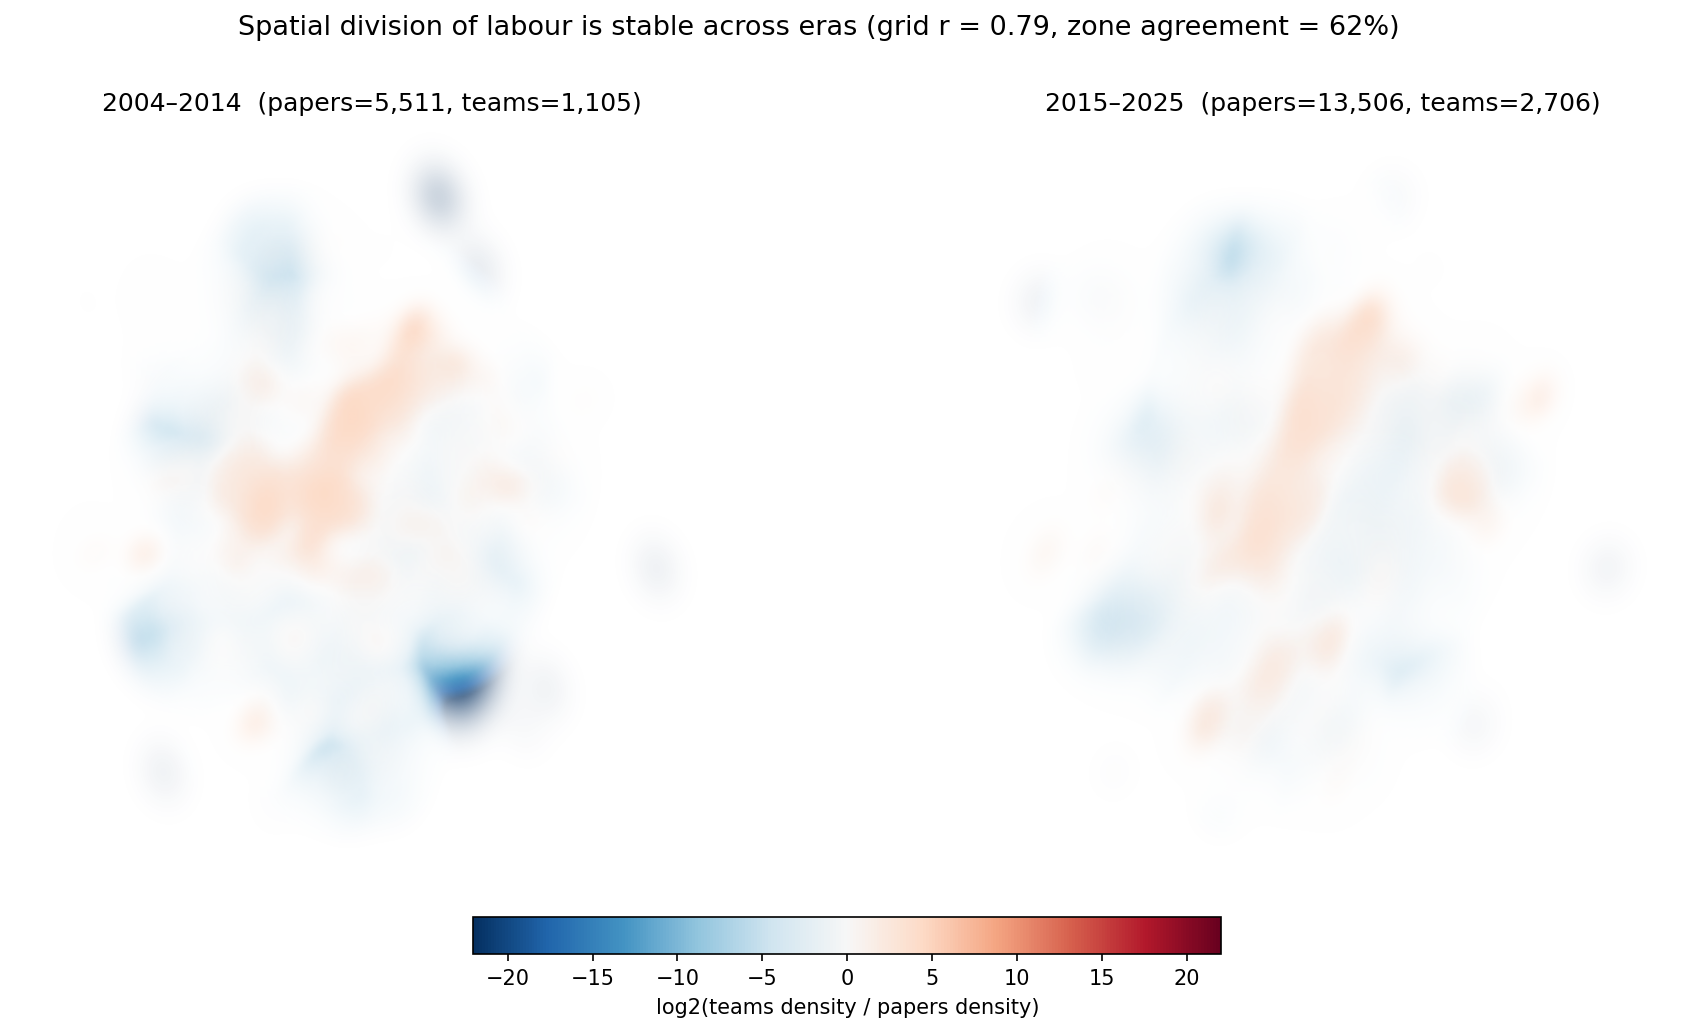

<Figure size 640x480 with 0 Axes>

In [2]:
%run density_eras.py

## 2 · Geographic specialization — Location Quotient

`LQ_c = (country c's share of iGEM teams) / (country c's share of SynBio papers)`
over the 2004–2025 co-existence window. `LQ > 1` = outsider-tilted, `LQ < 1` =
core/insider-tilted.

Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports/geography_lq.png

Totals — iGEM team-countries: 3,811 | paper-countries 2004-25: 21,229 | all-years: 21,229

TOP outsider-tilted (LQ>1, teams>=10):
country                teams  iGEM%   lit%     LQ   log2
Greece                    47   1.2%   0.2%   7.08   2.82
Kazakhstan                11   0.3%   0.0%   6.13   2.62
Mexico                    76   2.0%   0.4%   5.16   2.37
Hong Kong                 58   1.5%   0.3%   4.75   2.25
Taiwan                    89   2.3%   0.6%   3.76   1.91
Lithuania                 12   0.3%   0.1%   3.52   1.81
United Arab Emirates      11   0.3%   0.1%   2.19   1.13
Indonesia                 23   0.6%   0.3%   2.13   1.09
Sweden                    61   1.6%   0.9%   1.83   0.87
Canada                   207   5.4%   3.0%   1.82   0.86
China                    904  23.7%  13.8%   1.73   0.79
Turkey                    26   0.7%   0.4%   1.67   0.73
Norway                    21   0.6%   0.3%   

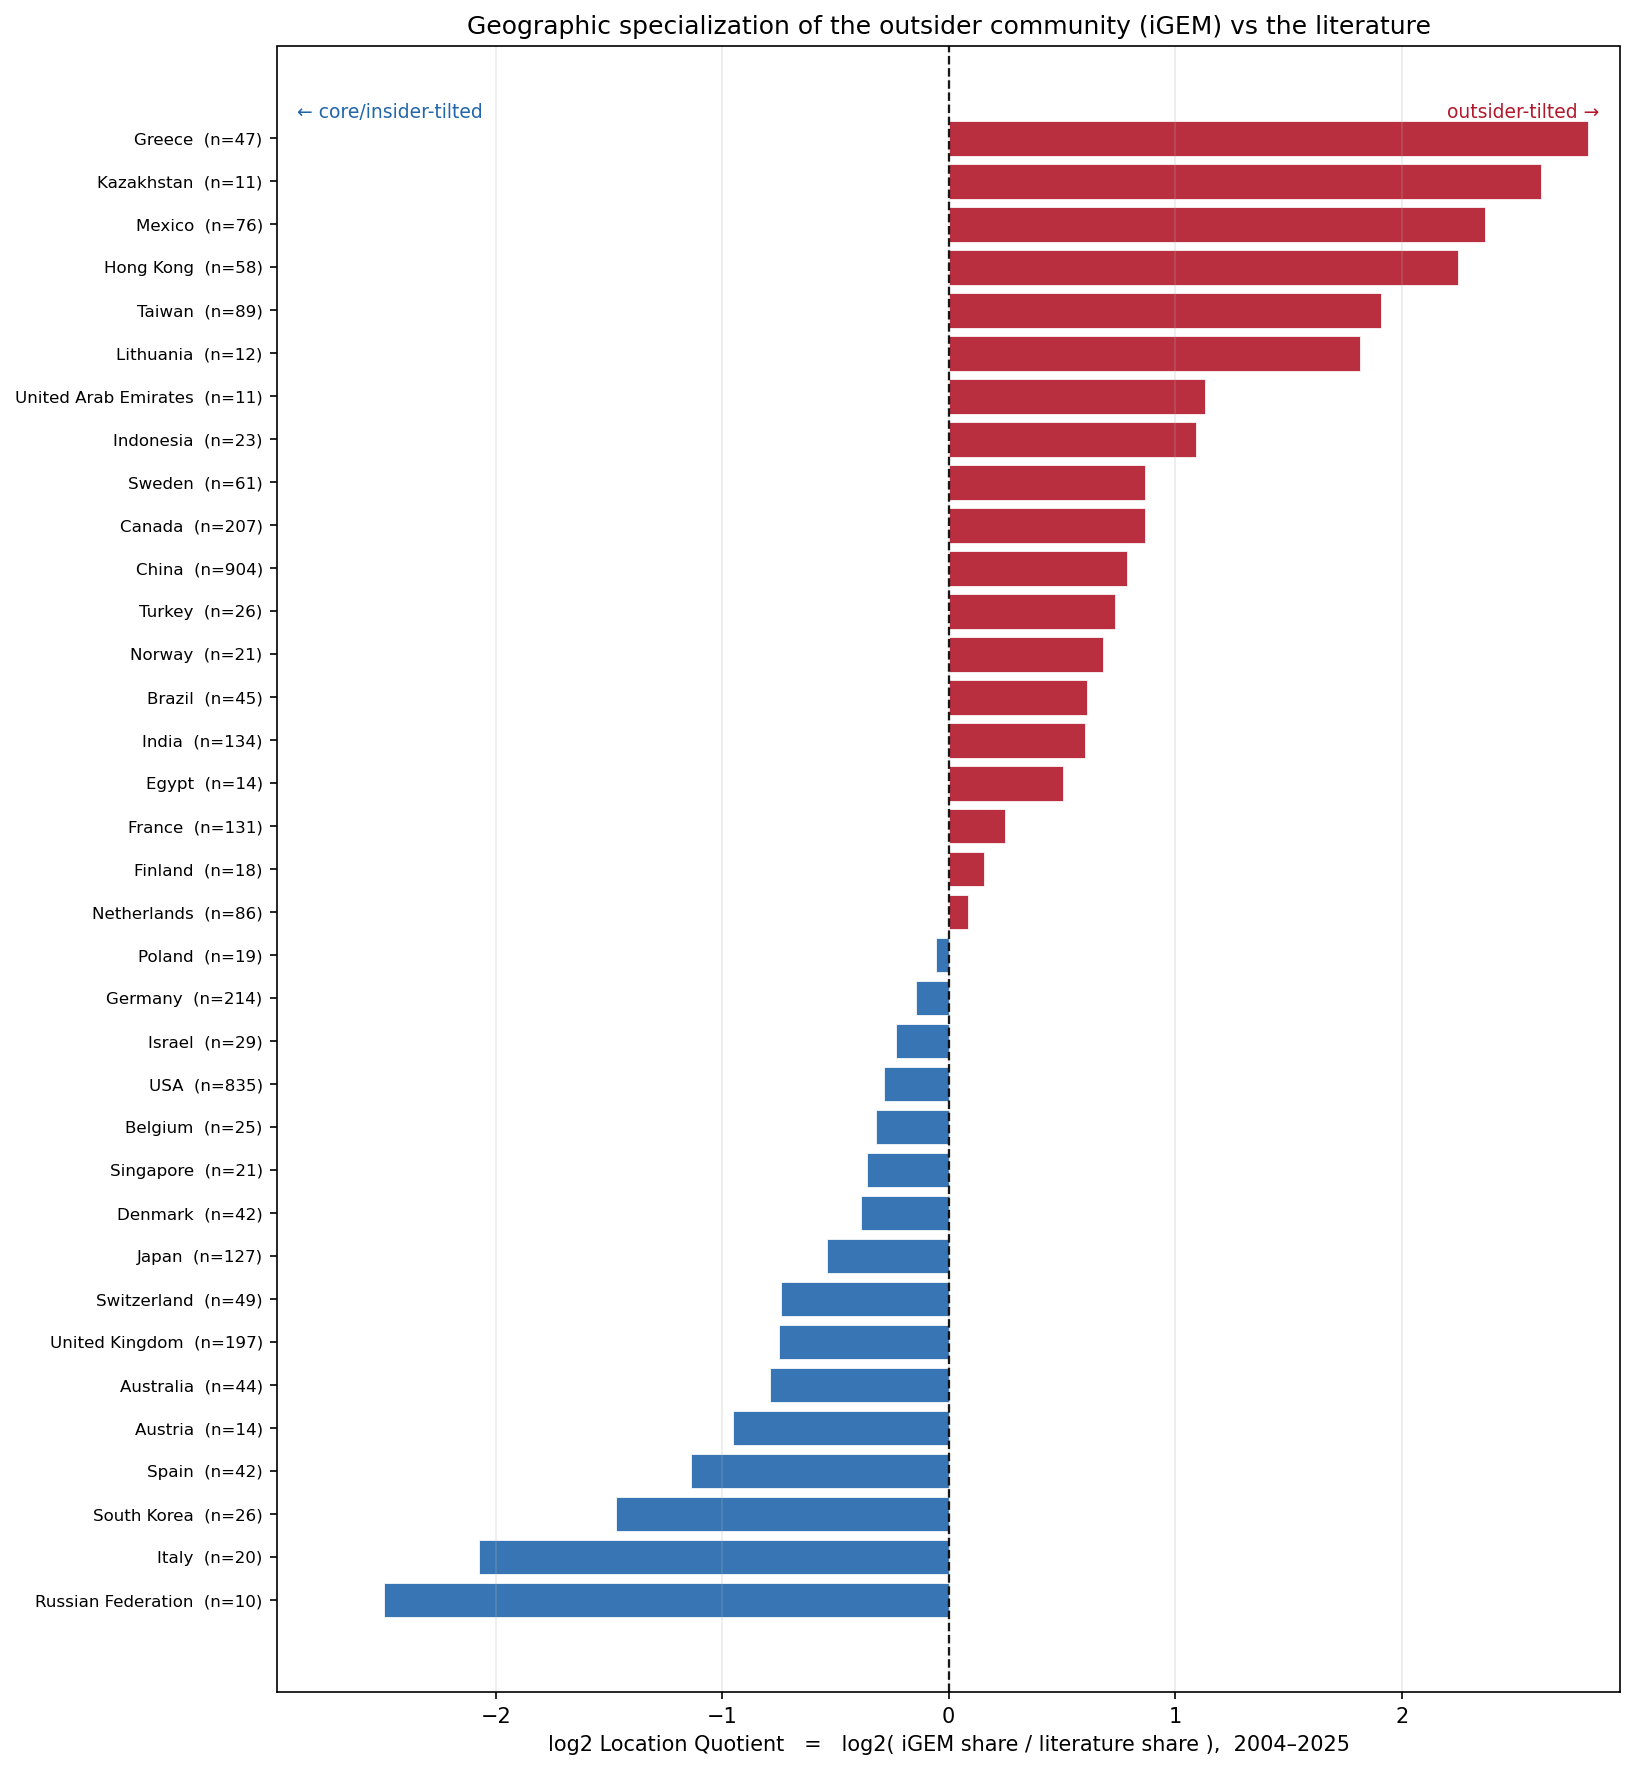

<Figure size 640x480 with 0 Axes>

In [3]:
%run geography_lq.py

## 3 · Country × overlap-topic matrix

Breaks each overlap topic's nearby teams down by country and tests whether
outsider-tilted (high-LQ) countries concentrate in the iGEM-led topics.

> Depends on the `geography_location_quotient.tsv` written by §2 above.

HYPOTHESIS: do outsider-tilted countries concentrate in iGEM-led topics?
  corr(country log2-LQ, precedence orientation): Pearson r=0.444 (p=0.007), Spearman rho=0.349 (p=0.040)
  (negative r => higher-LQ/outsider countries sit in more iGEM-led topics)

  Outsider-tilted countries (LQ>1, n=19): mean orientation delta_q1 = +0.26, mean frac in iGEM-led topics = 0.56
  Core-tilted countries    (LQ<1, n=16): mean orientation delta_q1 = -0.97, mean frac in iGEM-led topics = 0.68

Per-country (ordered as the matrix rows, top = most outsider-tilted):
  country               LQ  orient %iGEMlead  nearby
  Greece              7.08   +3.27       23%      22
  Kazakhstan          6.13   +6.75        0%       4
  Mexico              5.16   -1.30       72%      32
  Hong Kong           4.75   -0.35       53%      32
  Taiwan              3.76   +0.89       47%      32
  Lithuania           3.52   -2.00      100%       4
  United Arab Emirates  2.19   -1.22       62%       8
  Indonesia           2.

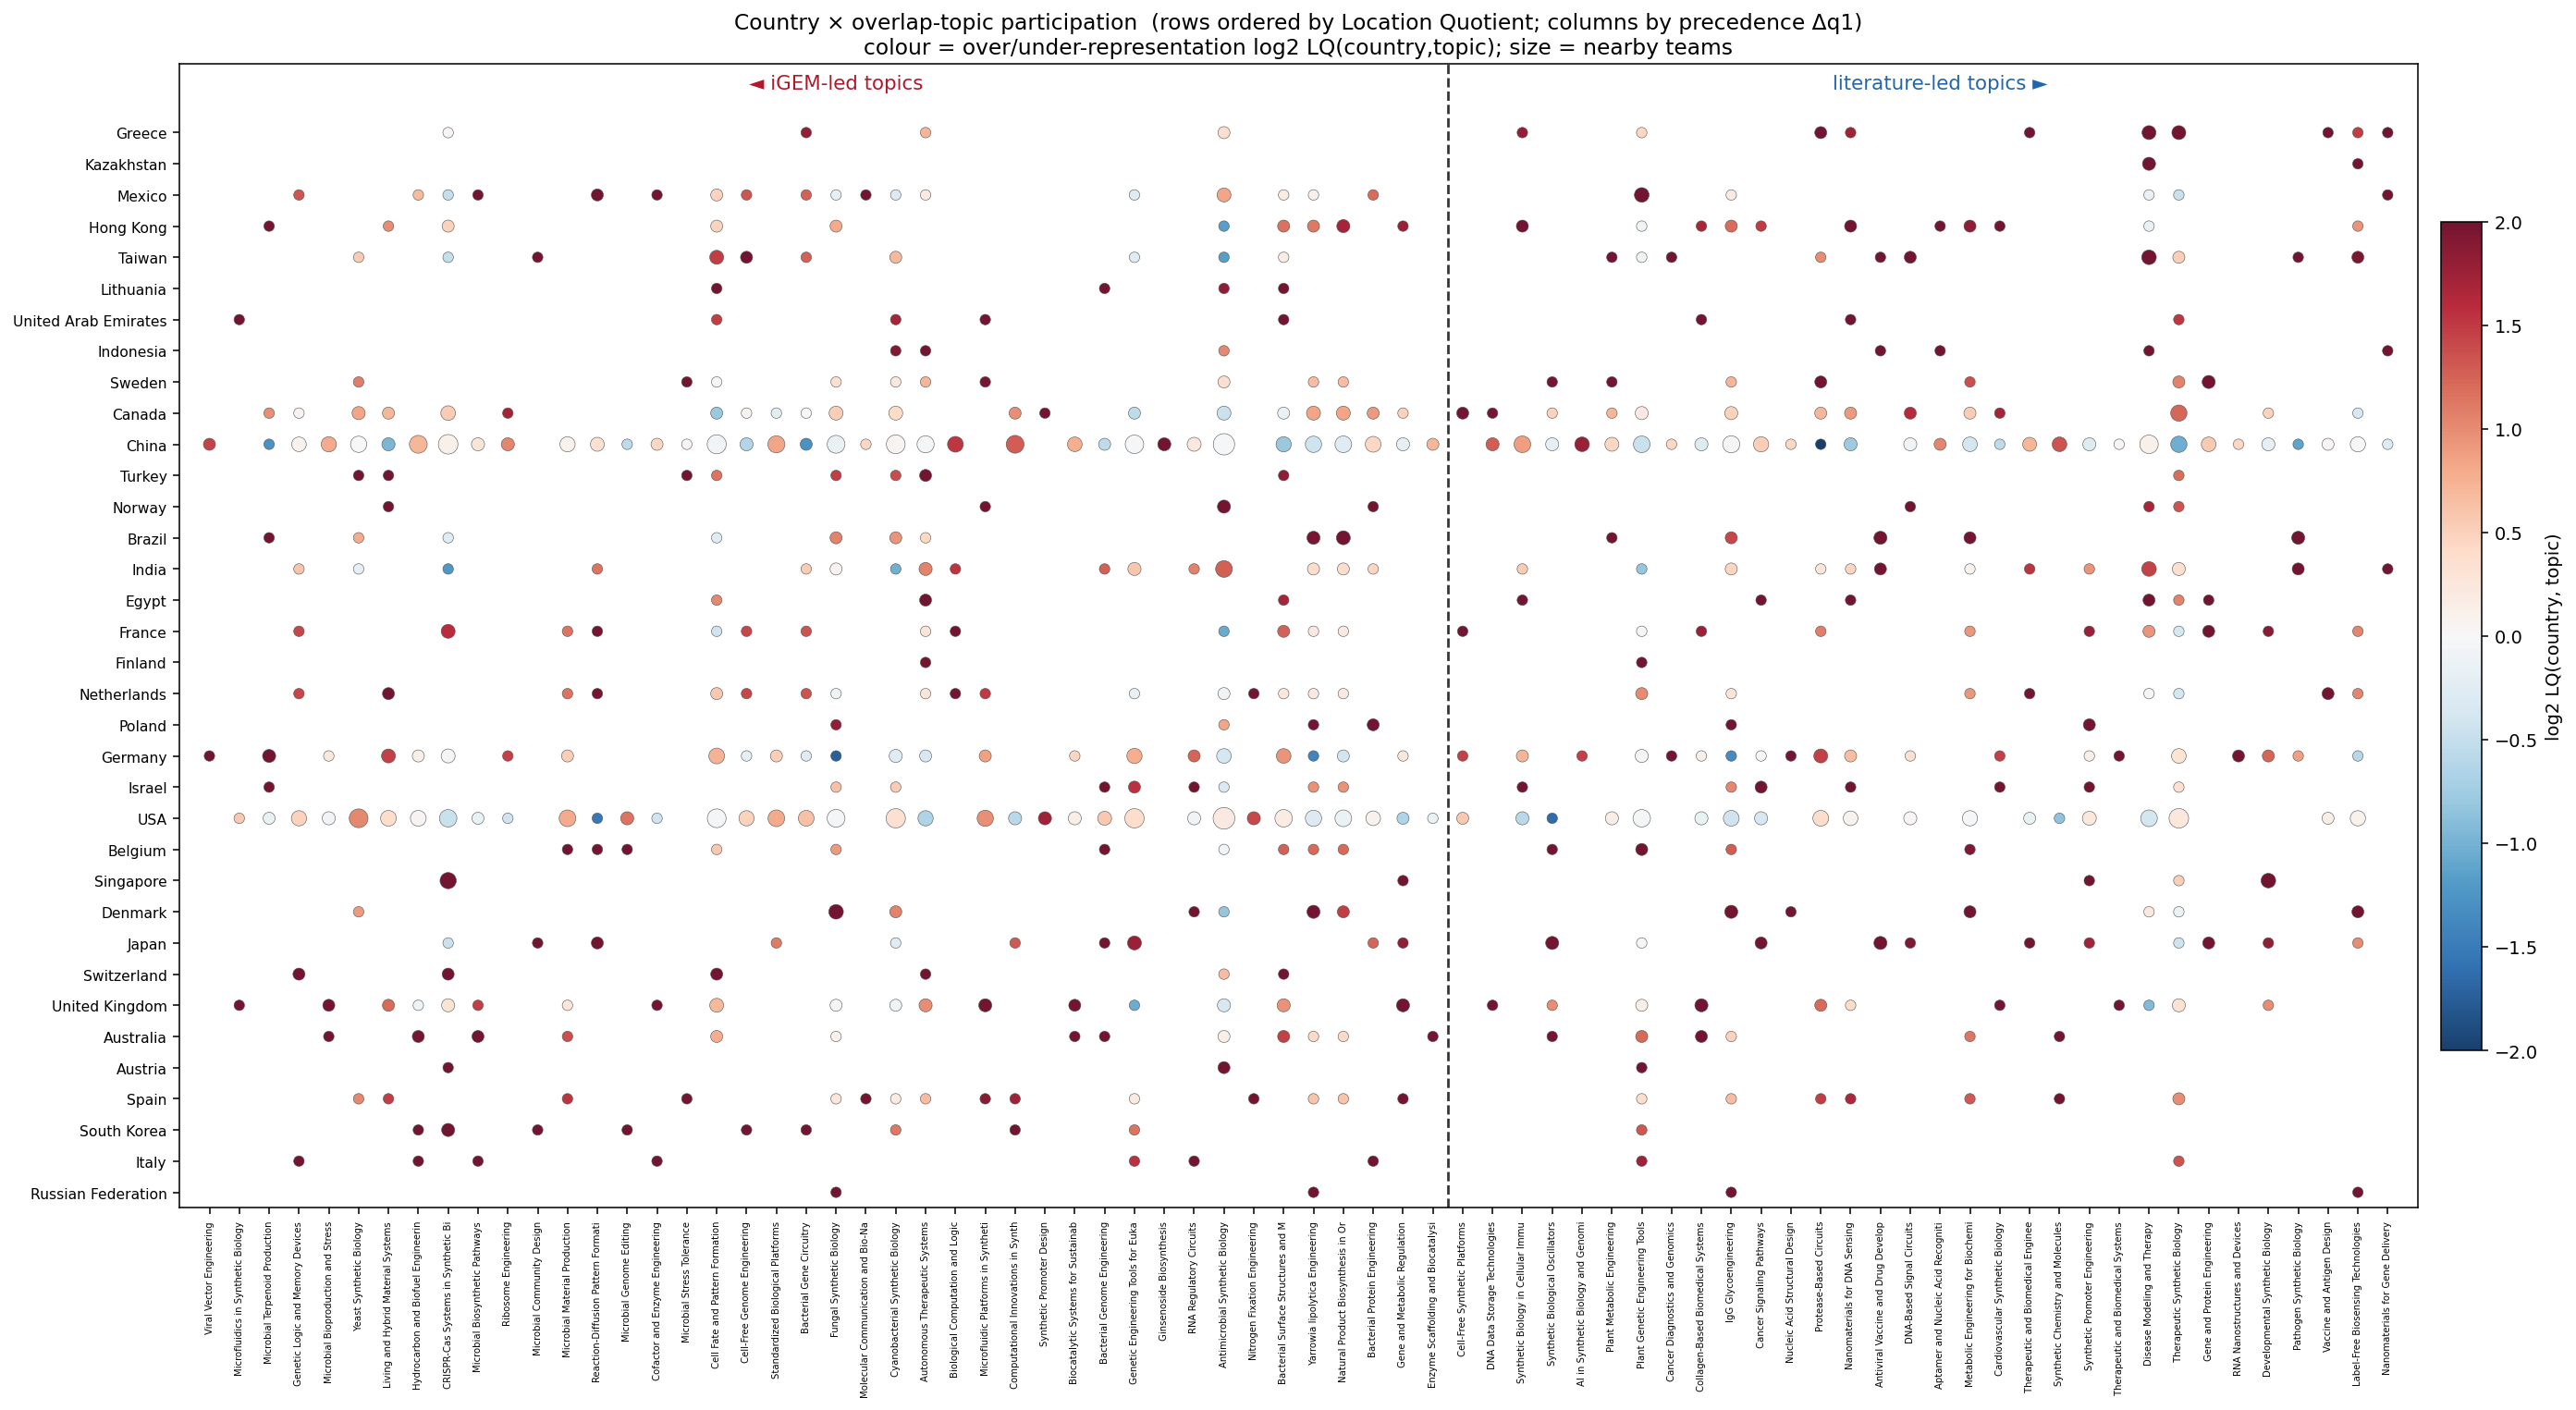

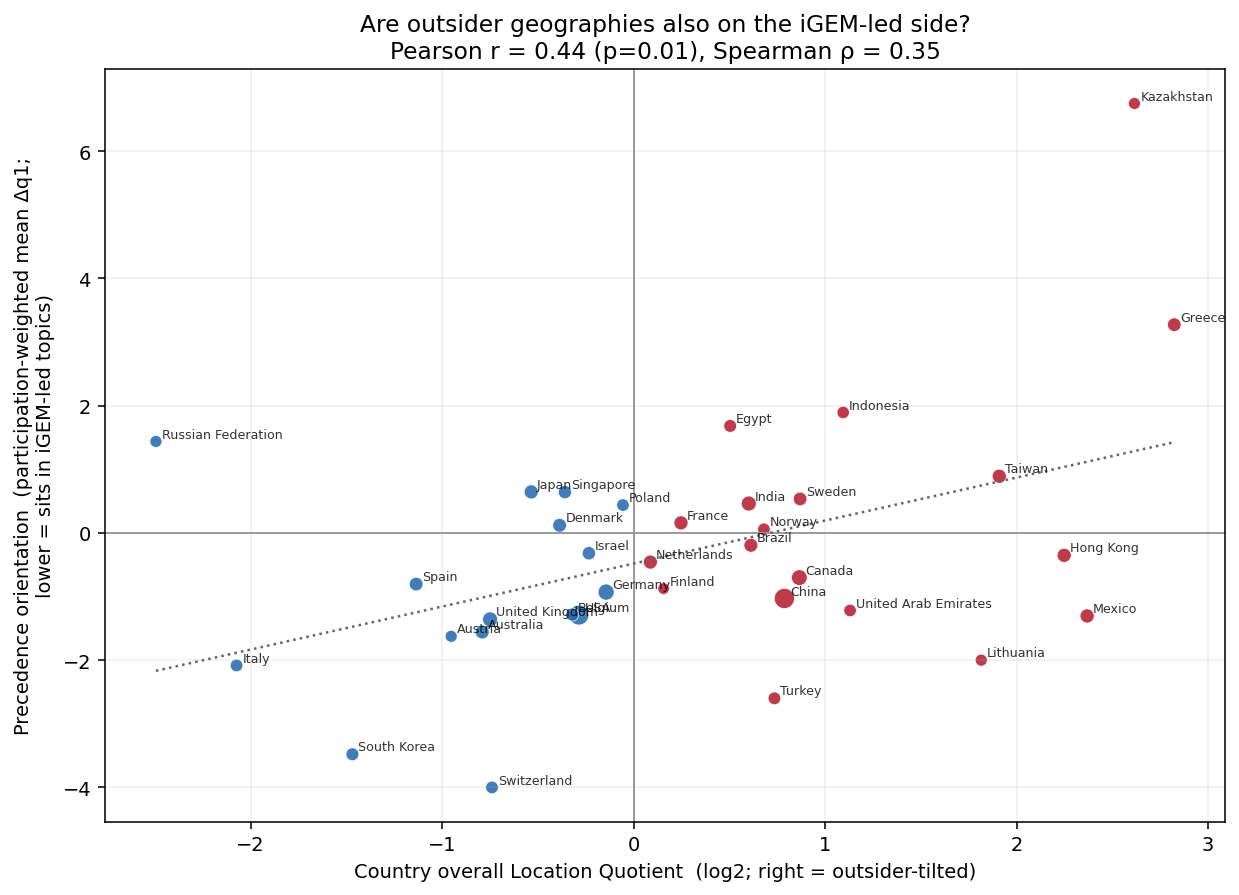

<Figure size 640x480 with 0 Axes>

In [4]:
%run geography_topic_matrix.py

## 4 · Outsiderness trajectories — do countries stop being outsiders?

§3 places each country on a static `(Location Quotient, precedence orientation)`
plane. The natural follow-up is to animate that plane over time. **Neither axis
can carry a trajectory**, for reasons that are mechanical rather than empirical:

1. **The precedence axis is circular with team timing.** `delta_q1_years =
   teams_q1_year − papers_q1_year`, so an early team can only sit near topics
   that are, by construction, iGEM-led. Destroy the country labels entirely and
   the pooled mean orientation still marches from −2.9 to +0.1 across the team-year
   cohorts. Any per-country trajectory on this axis reproduces that drift 19 times
   and calls it 19 findings.
2. **The LQ axis is compositional.** The paper-share-weighted mean of `LQ_c` is
   pinned to `1.0` in every window (verified: 0.994, 0.994, 1.000, 1.000 over four
   windows). A *global* decline in outsiderness is therefore unobservable in LQ
   space — only redistribution between countries is.

So this section measures outsiderness with a **spatial field** instead. Team years
never enter the field's construction and nothing is forced to sum to a constant,
so a country's line is free to fall:

$$\text{outsiderness}(\text{team}) \;=\; 1 - \Pr\big(\,\rho_{\text{lit}}(\text{random paper}) < \rho_{\text{lit}}(\text{team's location})\,\big)$$

An outsiderness of `0.80` means the team sits in a region of the joint map sparser
than where 80% of the literature sits. The literature density $\rho_{\text{lit}}$ is
estimated **contemporaneously** — from papers published up to and including the
team's own year — which asks the honest question: *at the time this team worked,
had the literature arrived there yet?*

That choice is load-bearing, and `geography_outsiderness_field_check.png` shows why.
Pooling all years into one fixed field scores an early pioneer against literature
that did not yet exist, marking it as an insider; this manufactures a spurious
`+0.0069/yr` rise in outsiderness (9.9σ) where the contemporaneous field finds
`+0.0001/yr` (0.2σ). The two fields correlate at Spearman ≈ 0.95 cross-sectionally
yet disagree completely on the time trend — the signature of the artefact.

> Depends on the `geography_location_quotient.tsv` written by §2 (used only to
> colour countries by their overall outsider/core tilt).

papers with xy+year: 19,017   teams with xy+year: 3,811

outsiderness (contemporaneous): mean 0.809  sd 0.211
corr(contemp, fixed)  = +0.847   (Spearman +0.881)
corr(contemp, log2 density-ratio) = +0.732   (Spearman +0.777)

GLOBAL trend, contemporaneous : -0.00298/yr  (SE 0.00068, 4.4σ, R²=0.0050)   total over 21 yr: -0.063
GLOBAL trend, fixed all-years: +0.00473/yr  (SE 0.00078, 6.1σ)   total over 21 yr: +0.099  ← artefact

countries plotted: 15  (BRA, CAN, CHN, DEU, DNK, FRA, GBR, HKG, IND, JPN, MEX, NLD, SWE, TWN, USA)

Per-country trend in outsiderness (contemporaneous field, team-level OLS):
  country                  n   early   late   slope/yr      σ  rel.slope
  Brazil                  45   0.933  0.801   -0.01361    2.2   -0.01193
  Hong Kong               58   0.894  0.735   -0.01182    2.2   -0.00957
  France                 131   0.831  0.742   -0.00726    1.6   -0.00484
  United Kingdom         197   0.892  0.789   -0.00677    2.4   -0.00386
  Taiwan                  89  

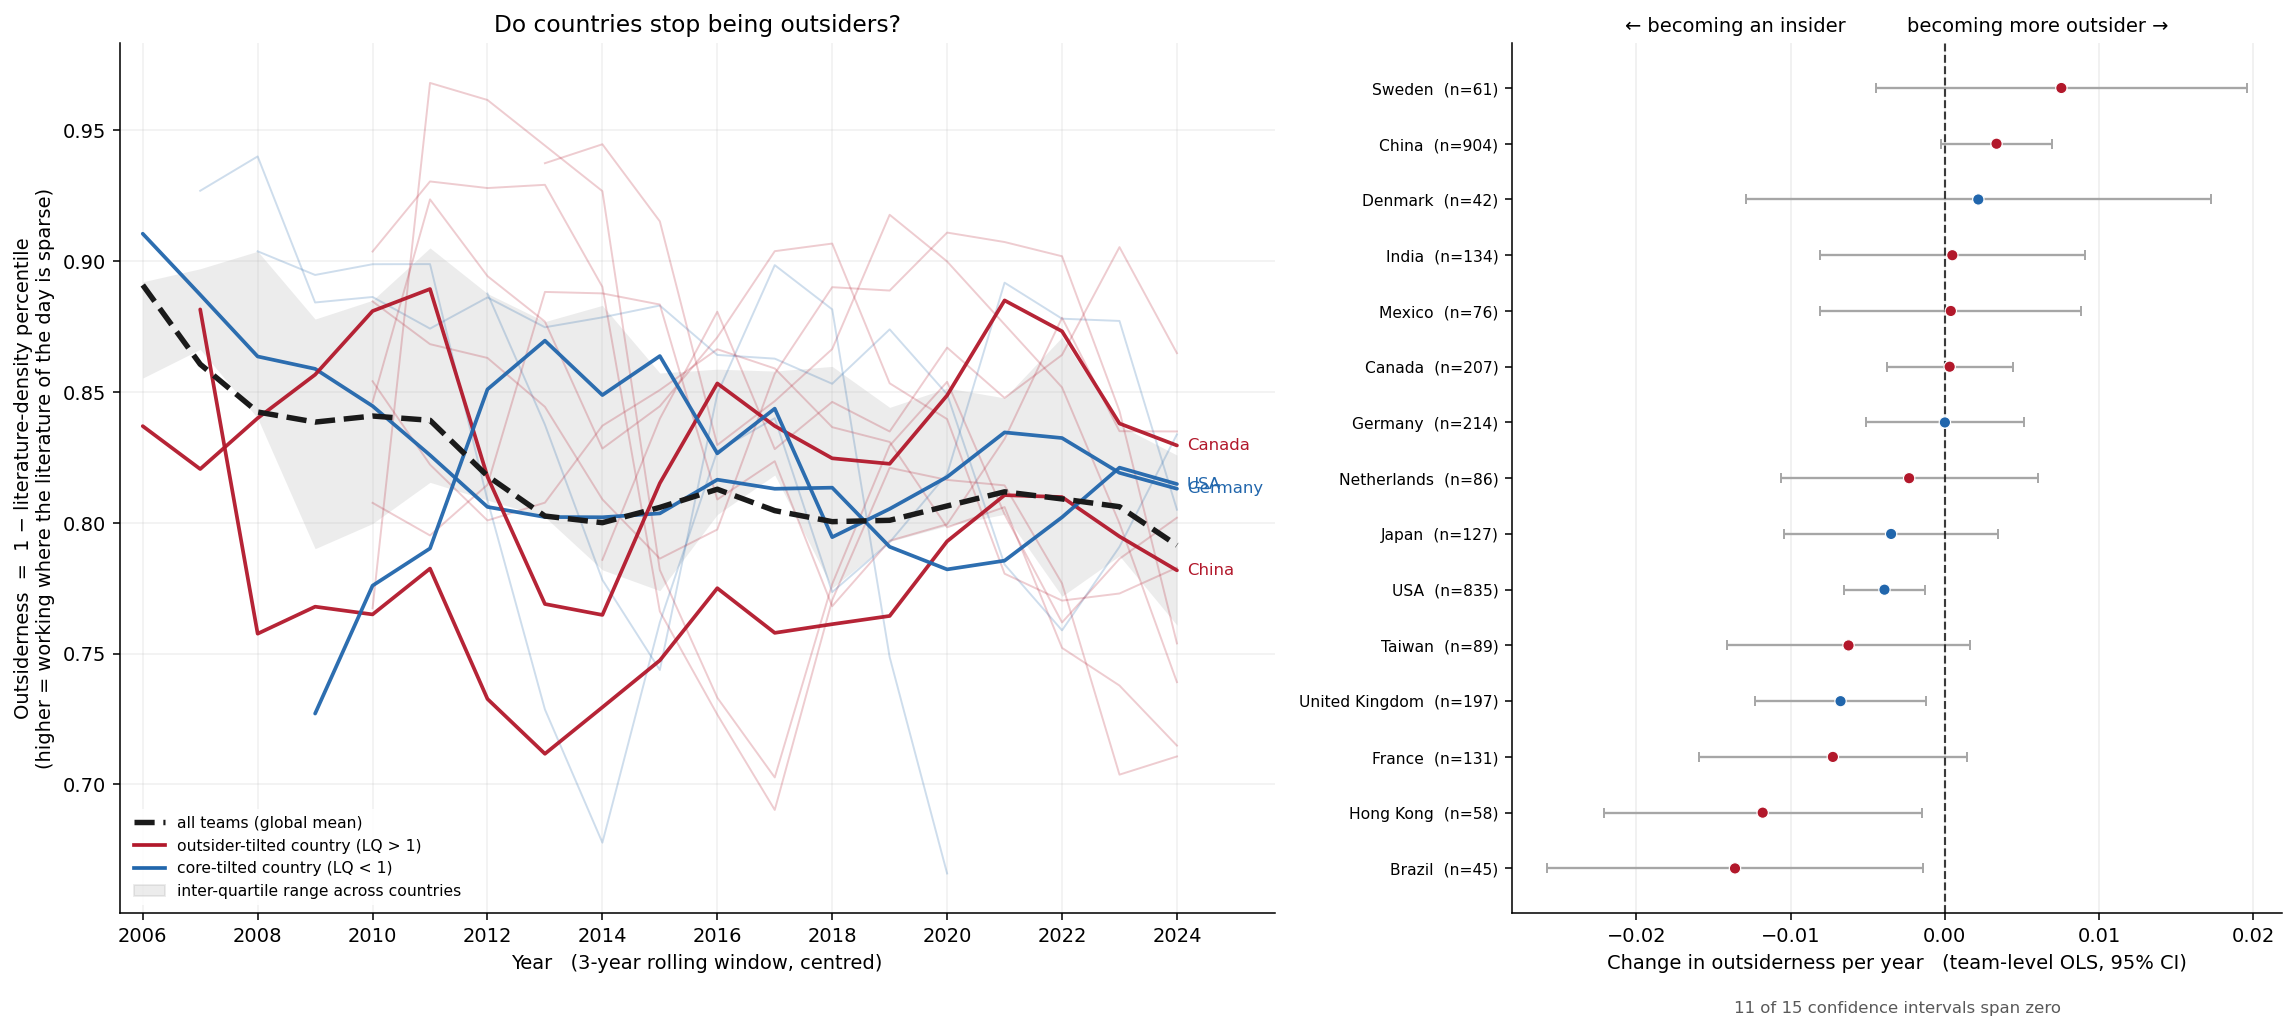

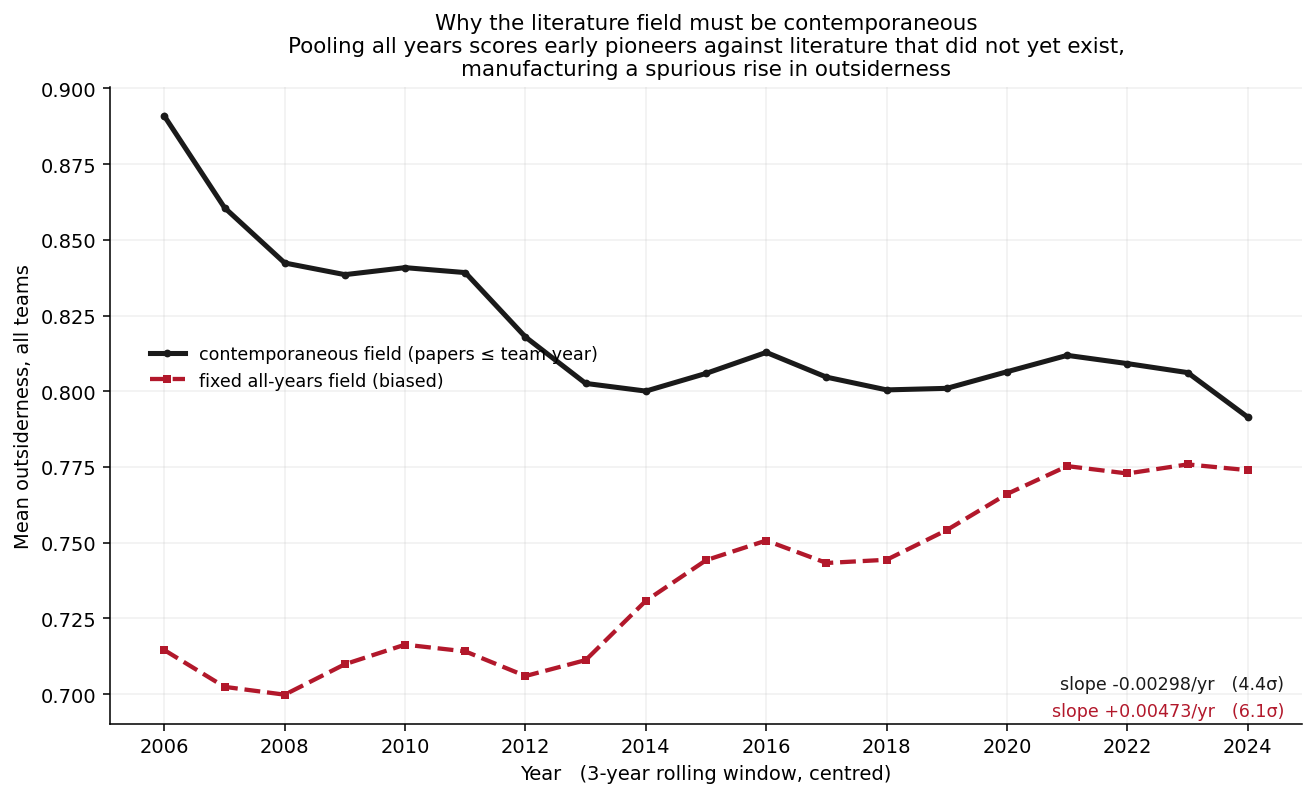

<Figure size 640x480 with 0 Axes>

In [5]:
%run geography_outsiderness.py

## 5 · Precedence robustness (R1)

Reproduces the shipped `overlap_precedence_full.tsv` as a correctness check, then
verifies (a) sign stability of the lead/lag direction across Q1 / median / mean
and (b) split stability across radius-multiplier × minimum-support parameters.

Reproduced 74 overlap topics (shipped: 74); max |delta_q1 diff| vs shipped = 0.000

(a) Sign stability across Q1 / median / mean:
    60/67 non-zero topics agree in sign across all three (90%).
    by delta_q1    : 42 iGEM-first, 29 papers-first
    by delta_median: 49 iGEM-first, 20 papers-first
    by delta_mean  : 47 iGEM-first, 27 papers-first

(b) Split stability across neighbourhood parameters (direction by delta_q1):
     radius min_n tested iGEM1st pap1st flips*
        1.0     3     58      34     21      7
        1.0     5     49      29     17      7
        1.0    10     24      17      7      3
        1.5     3     74      42     29      0
        1.5     5     62      35     24      0
        1.5    10     49      30     18      0
        2.0     3     79      51     27      4
        2.0     5     72      46     25      4
        2.0    10     55      37     17      4
    * sign flips of delta_q1 vs the default (1.5, 3) run, among shared topics.

Saved → /Users/cristia

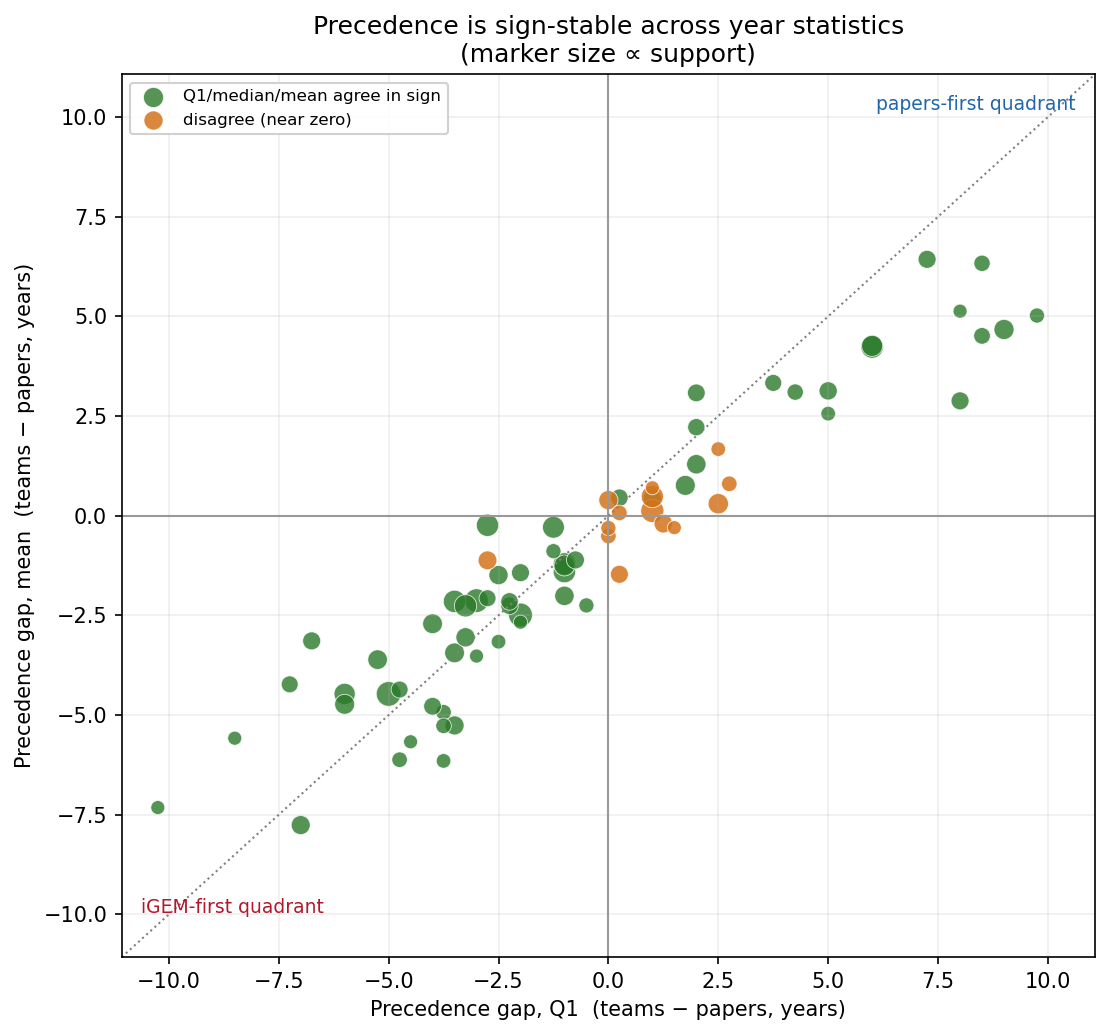

<Figure size 640x480 with 0 Axes>

In [6]:
%run precedence_robustness.py

## Generated figures

The PNGs produced above, embedded here so the appendix is self-contained.

── density_ratio_eras.png


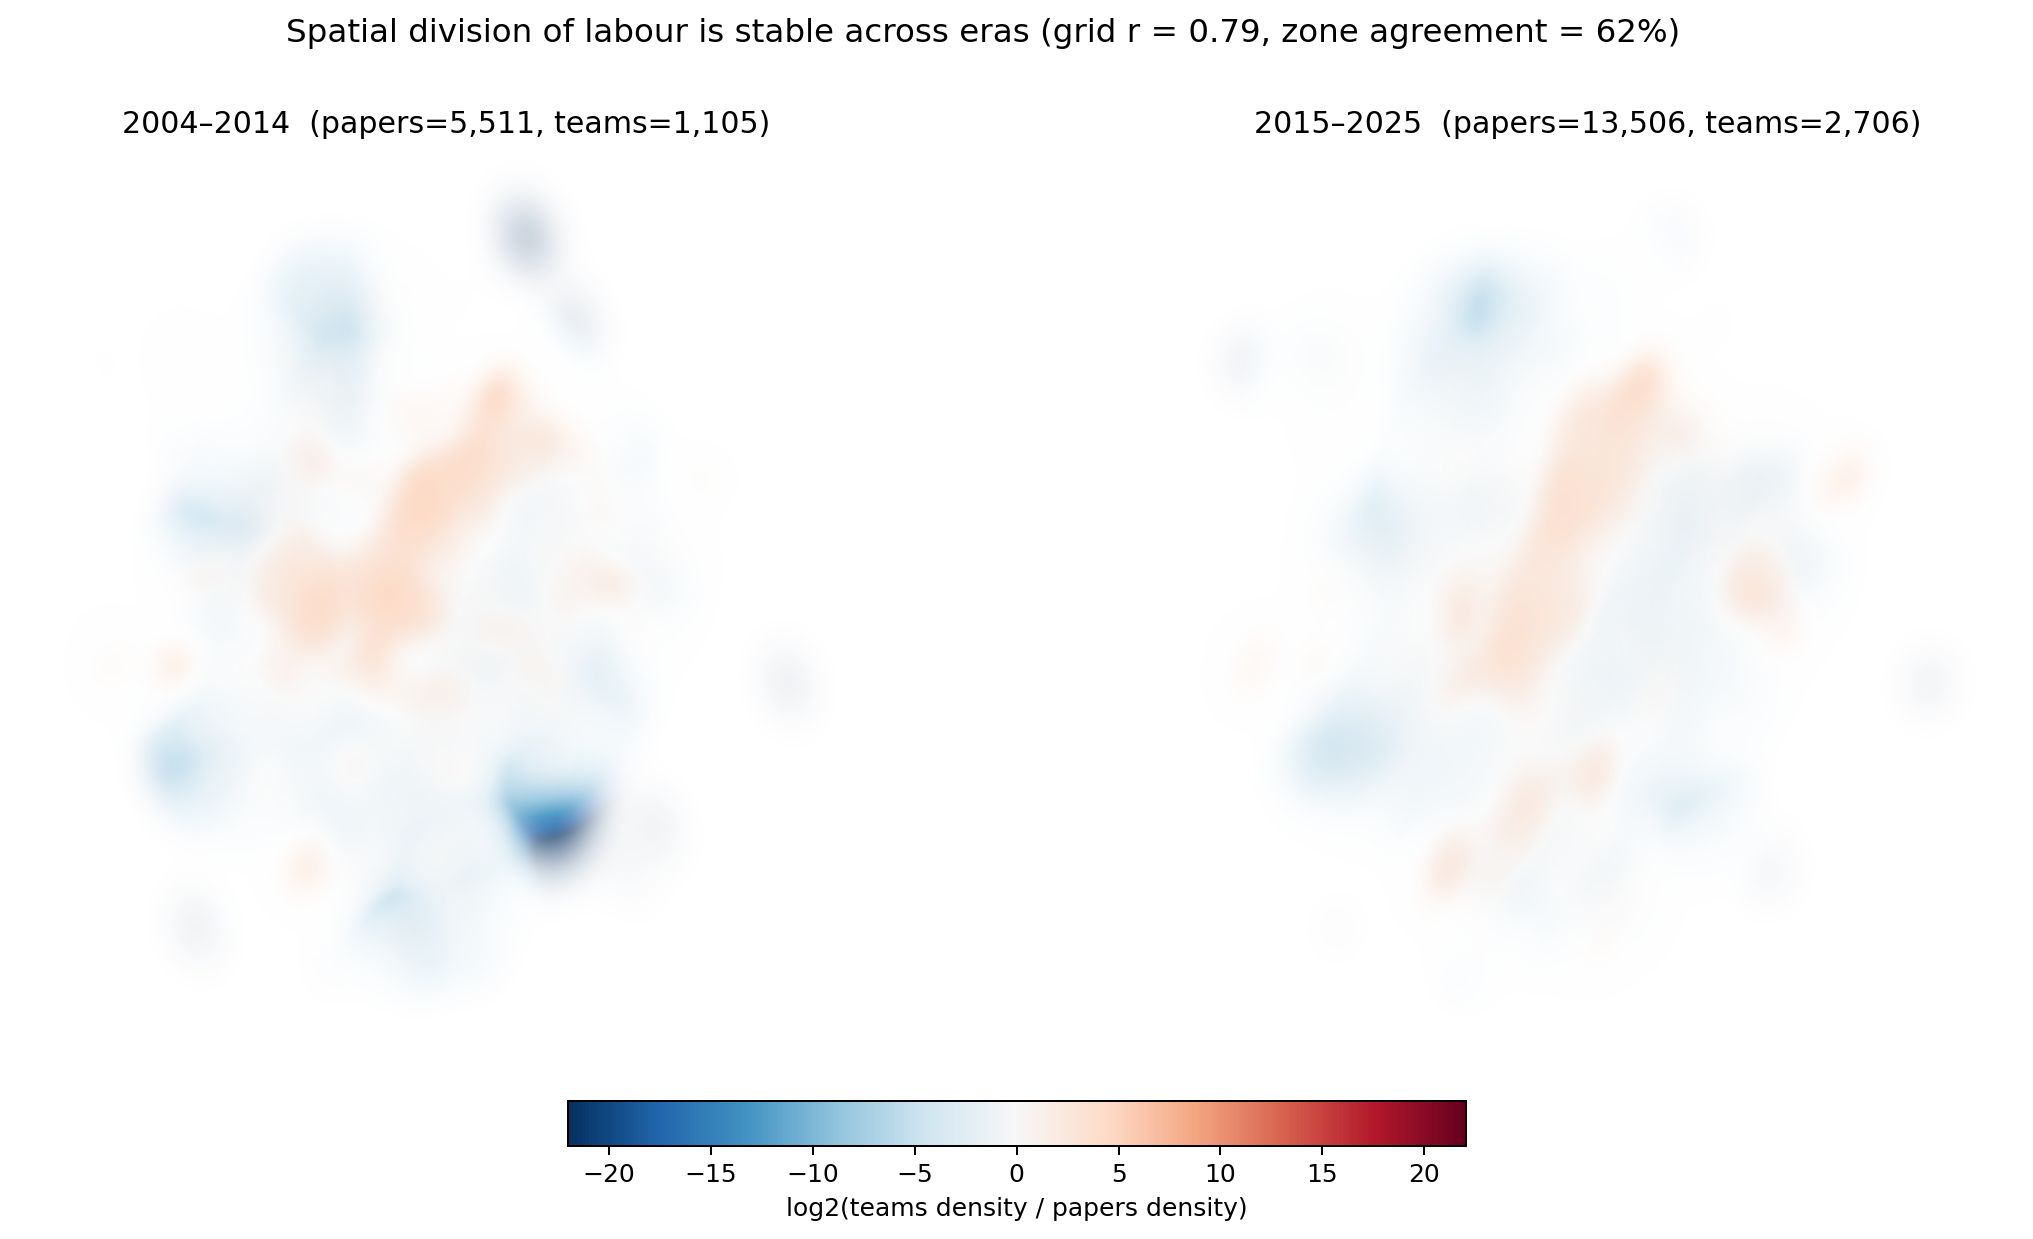

── geography_lq.png


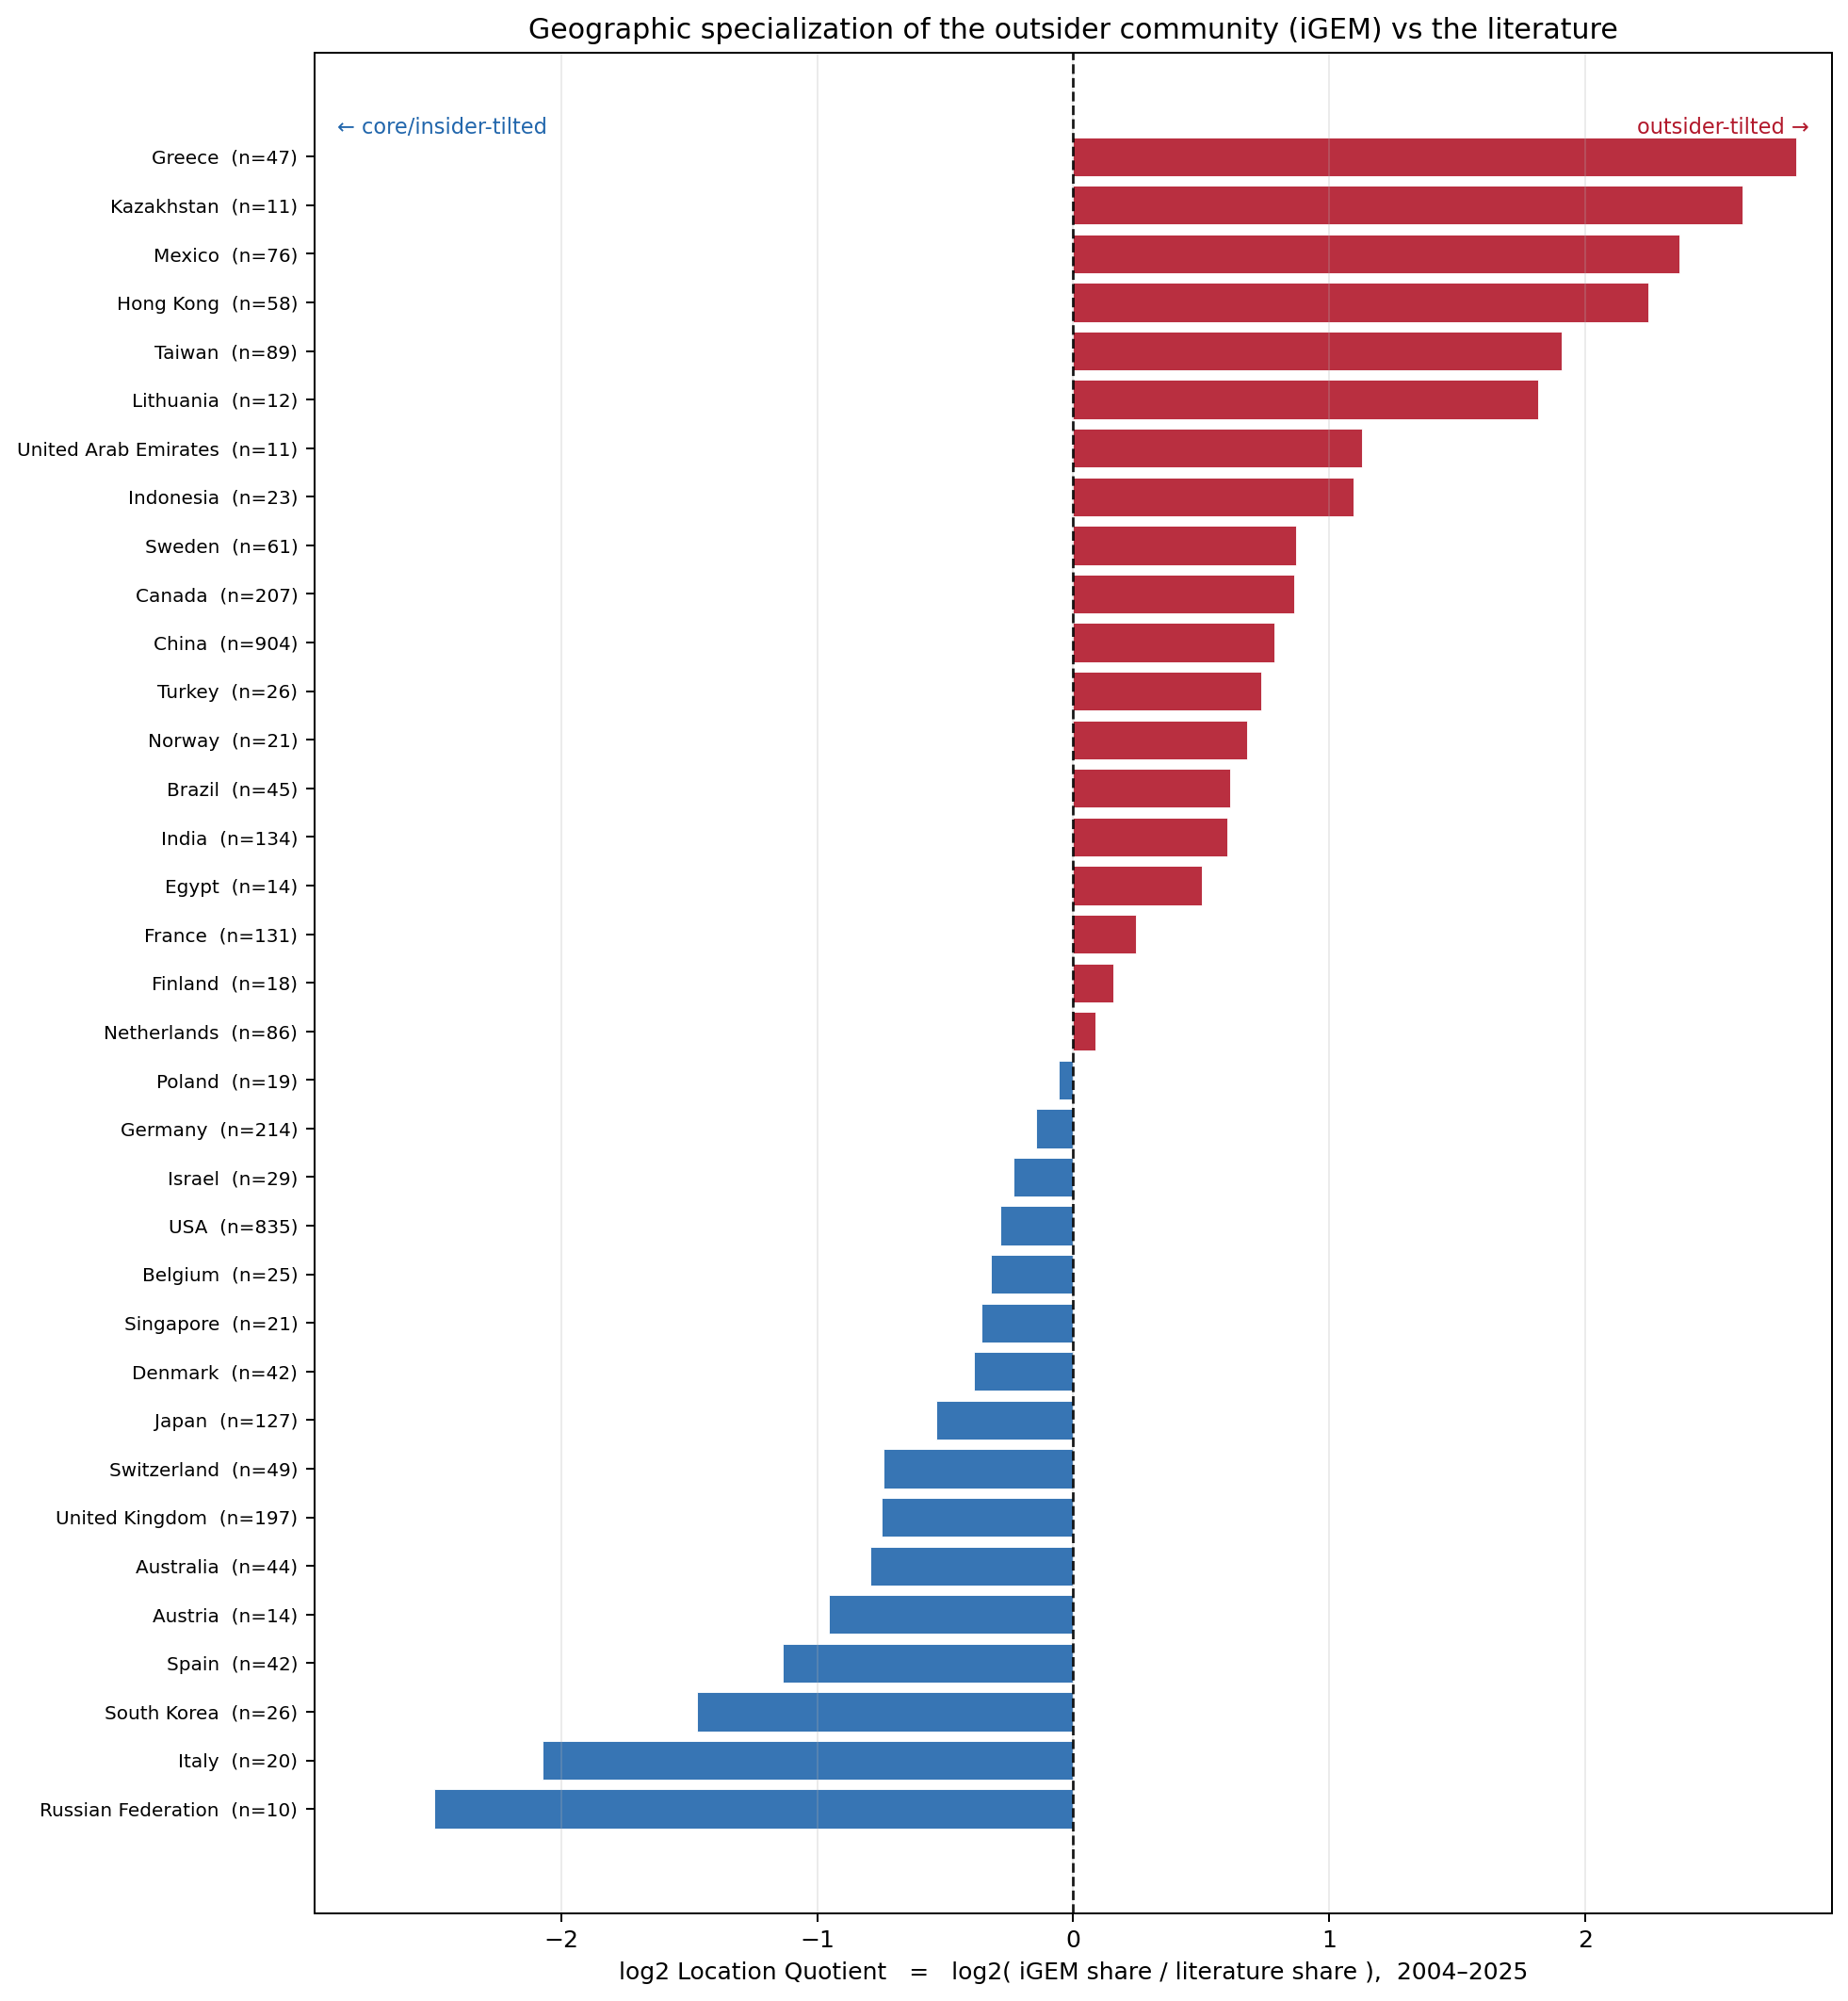

── geography_topic_matrix.png


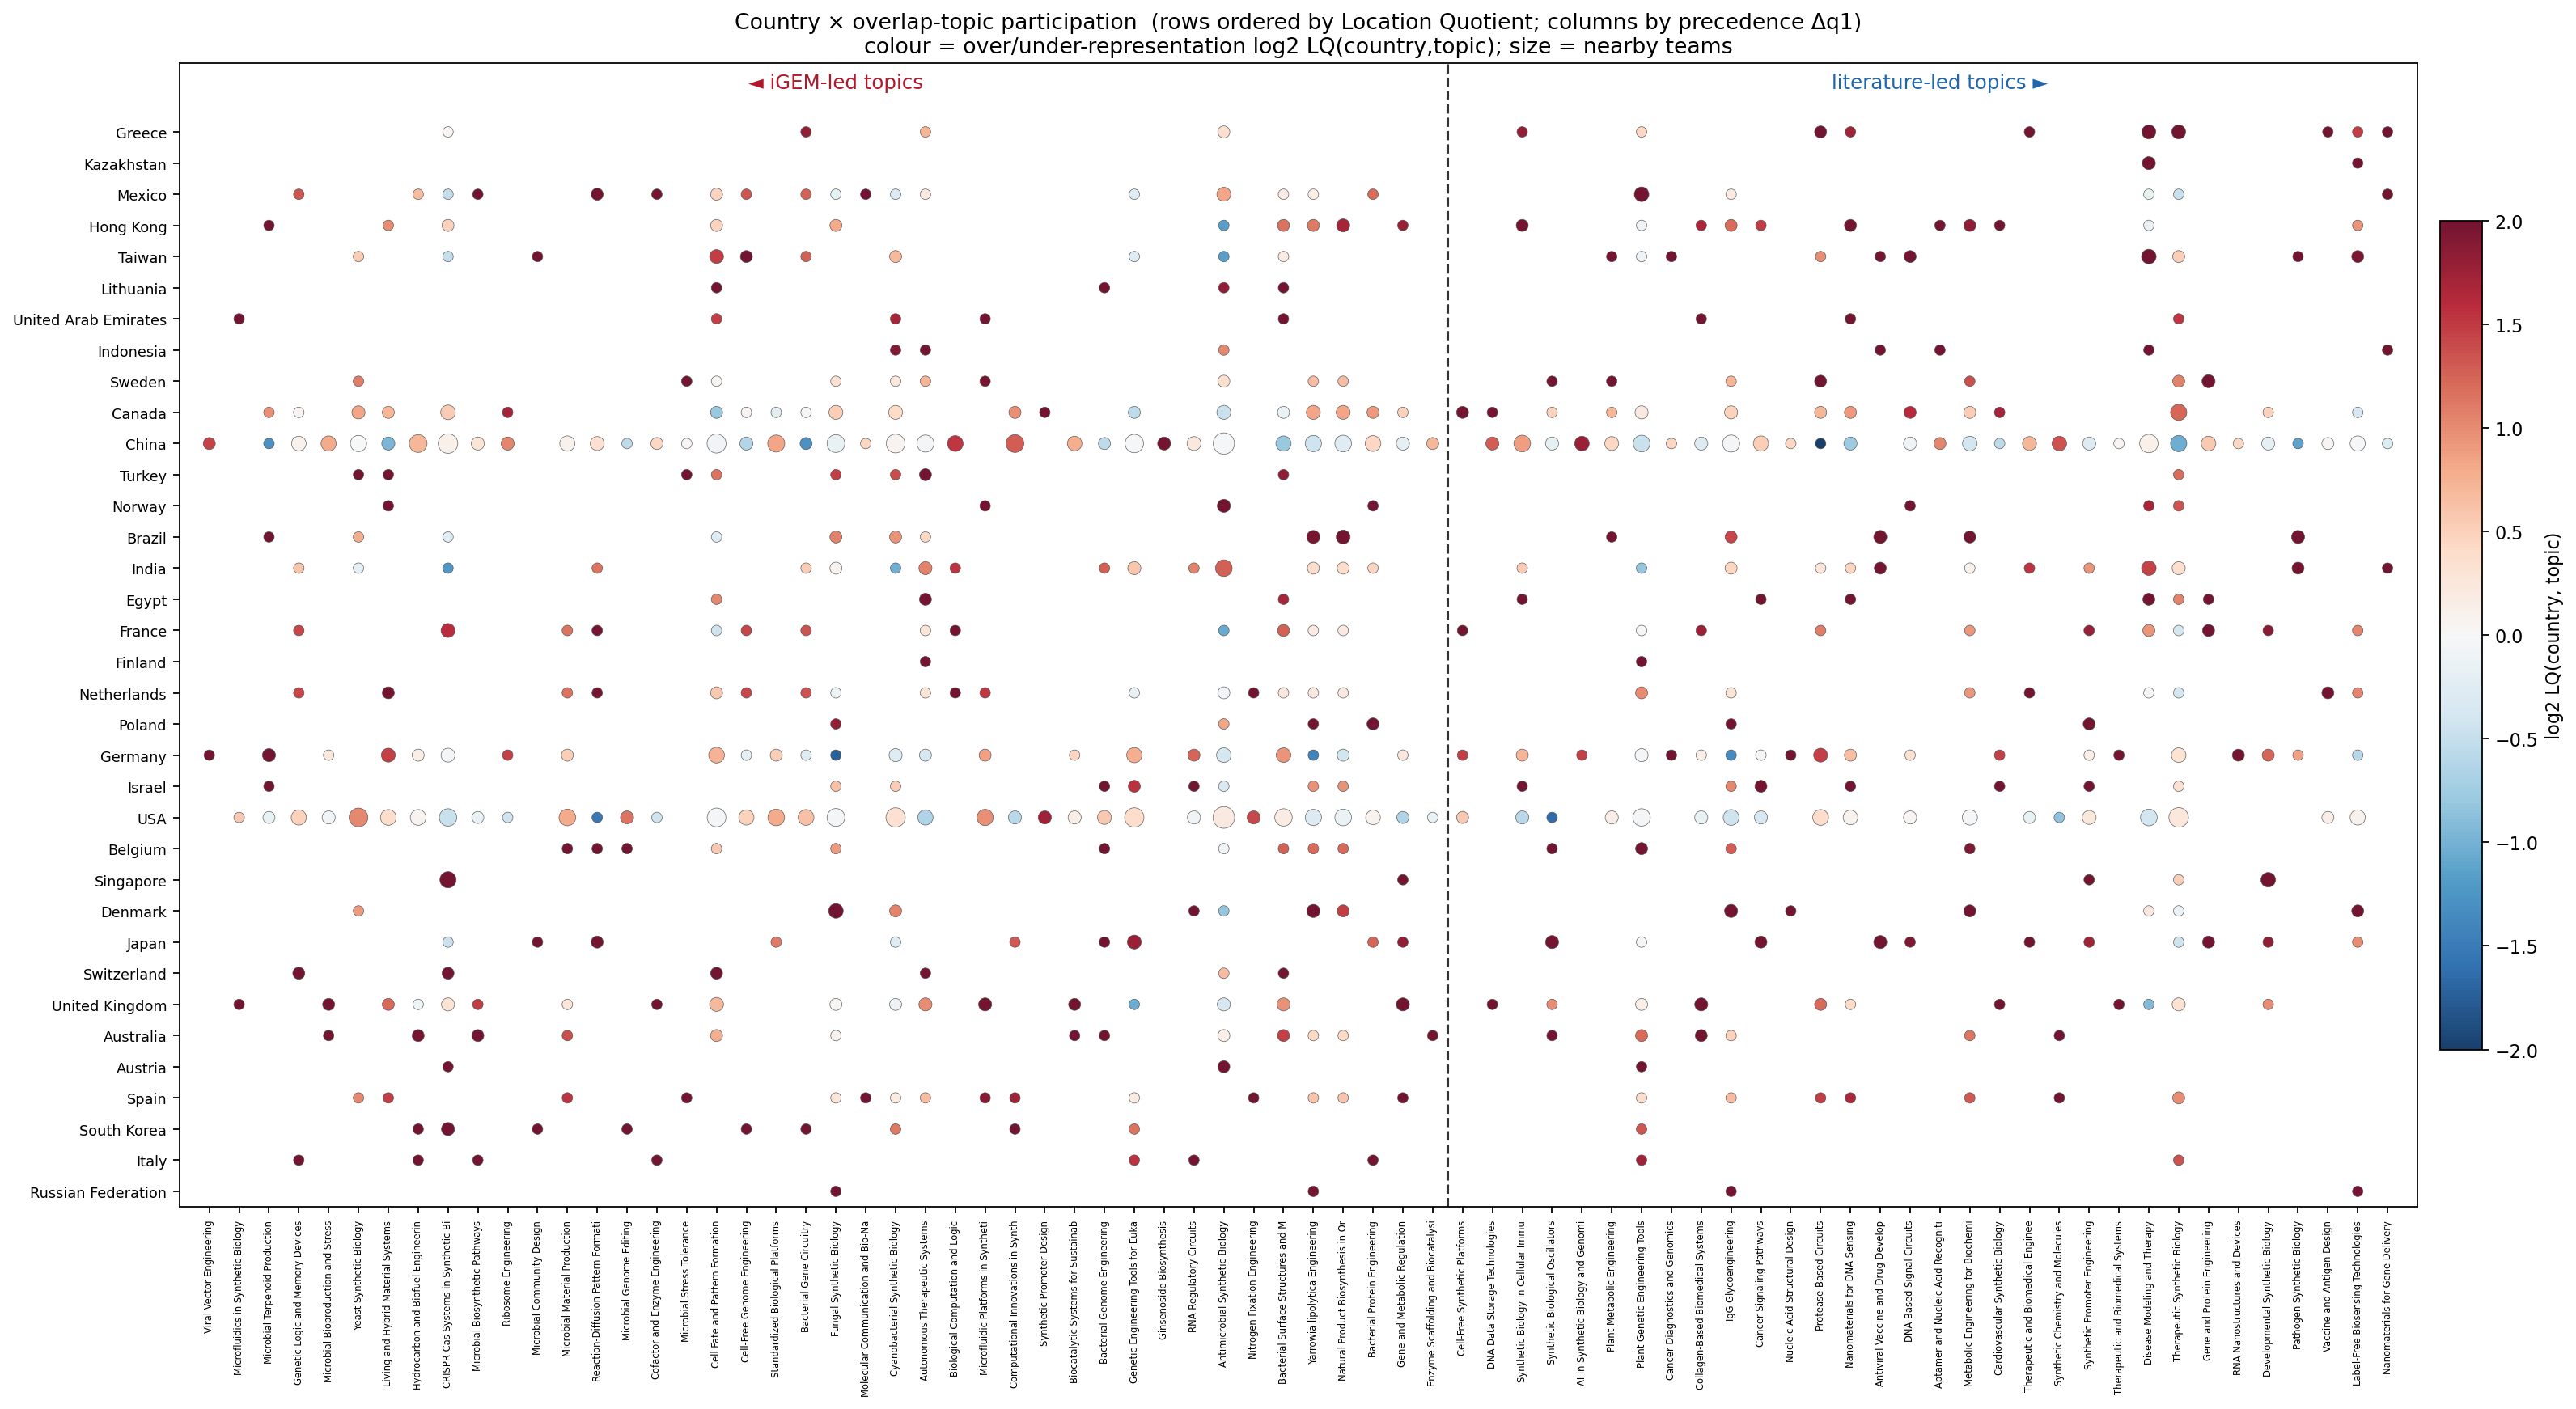

── geography_lead_orientation.png


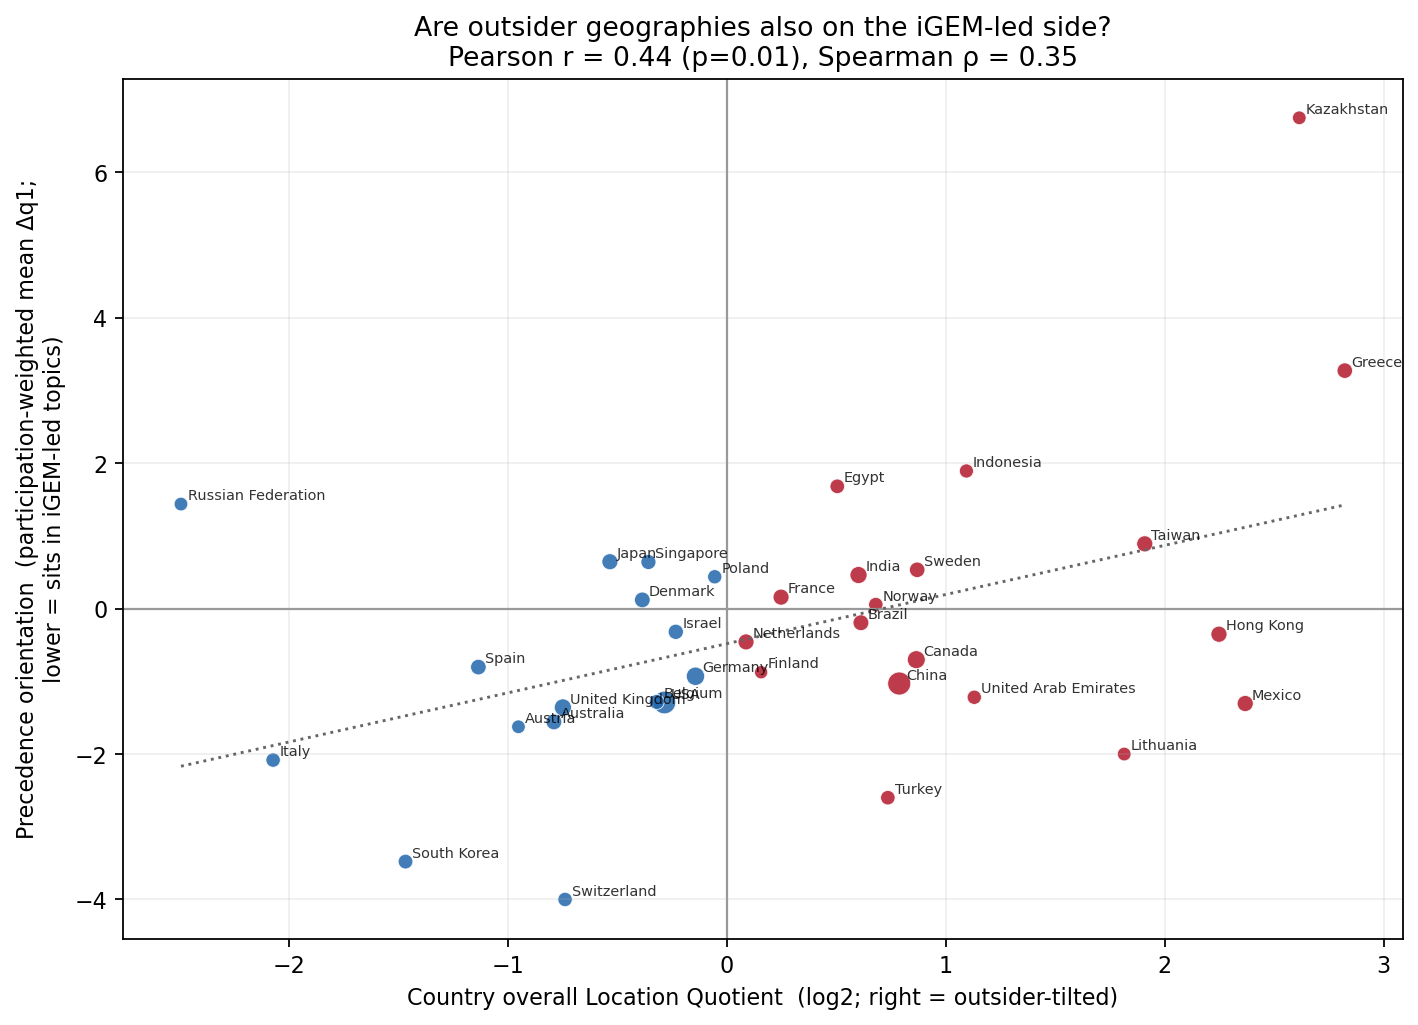

── geography_outsiderness_trajectory.png


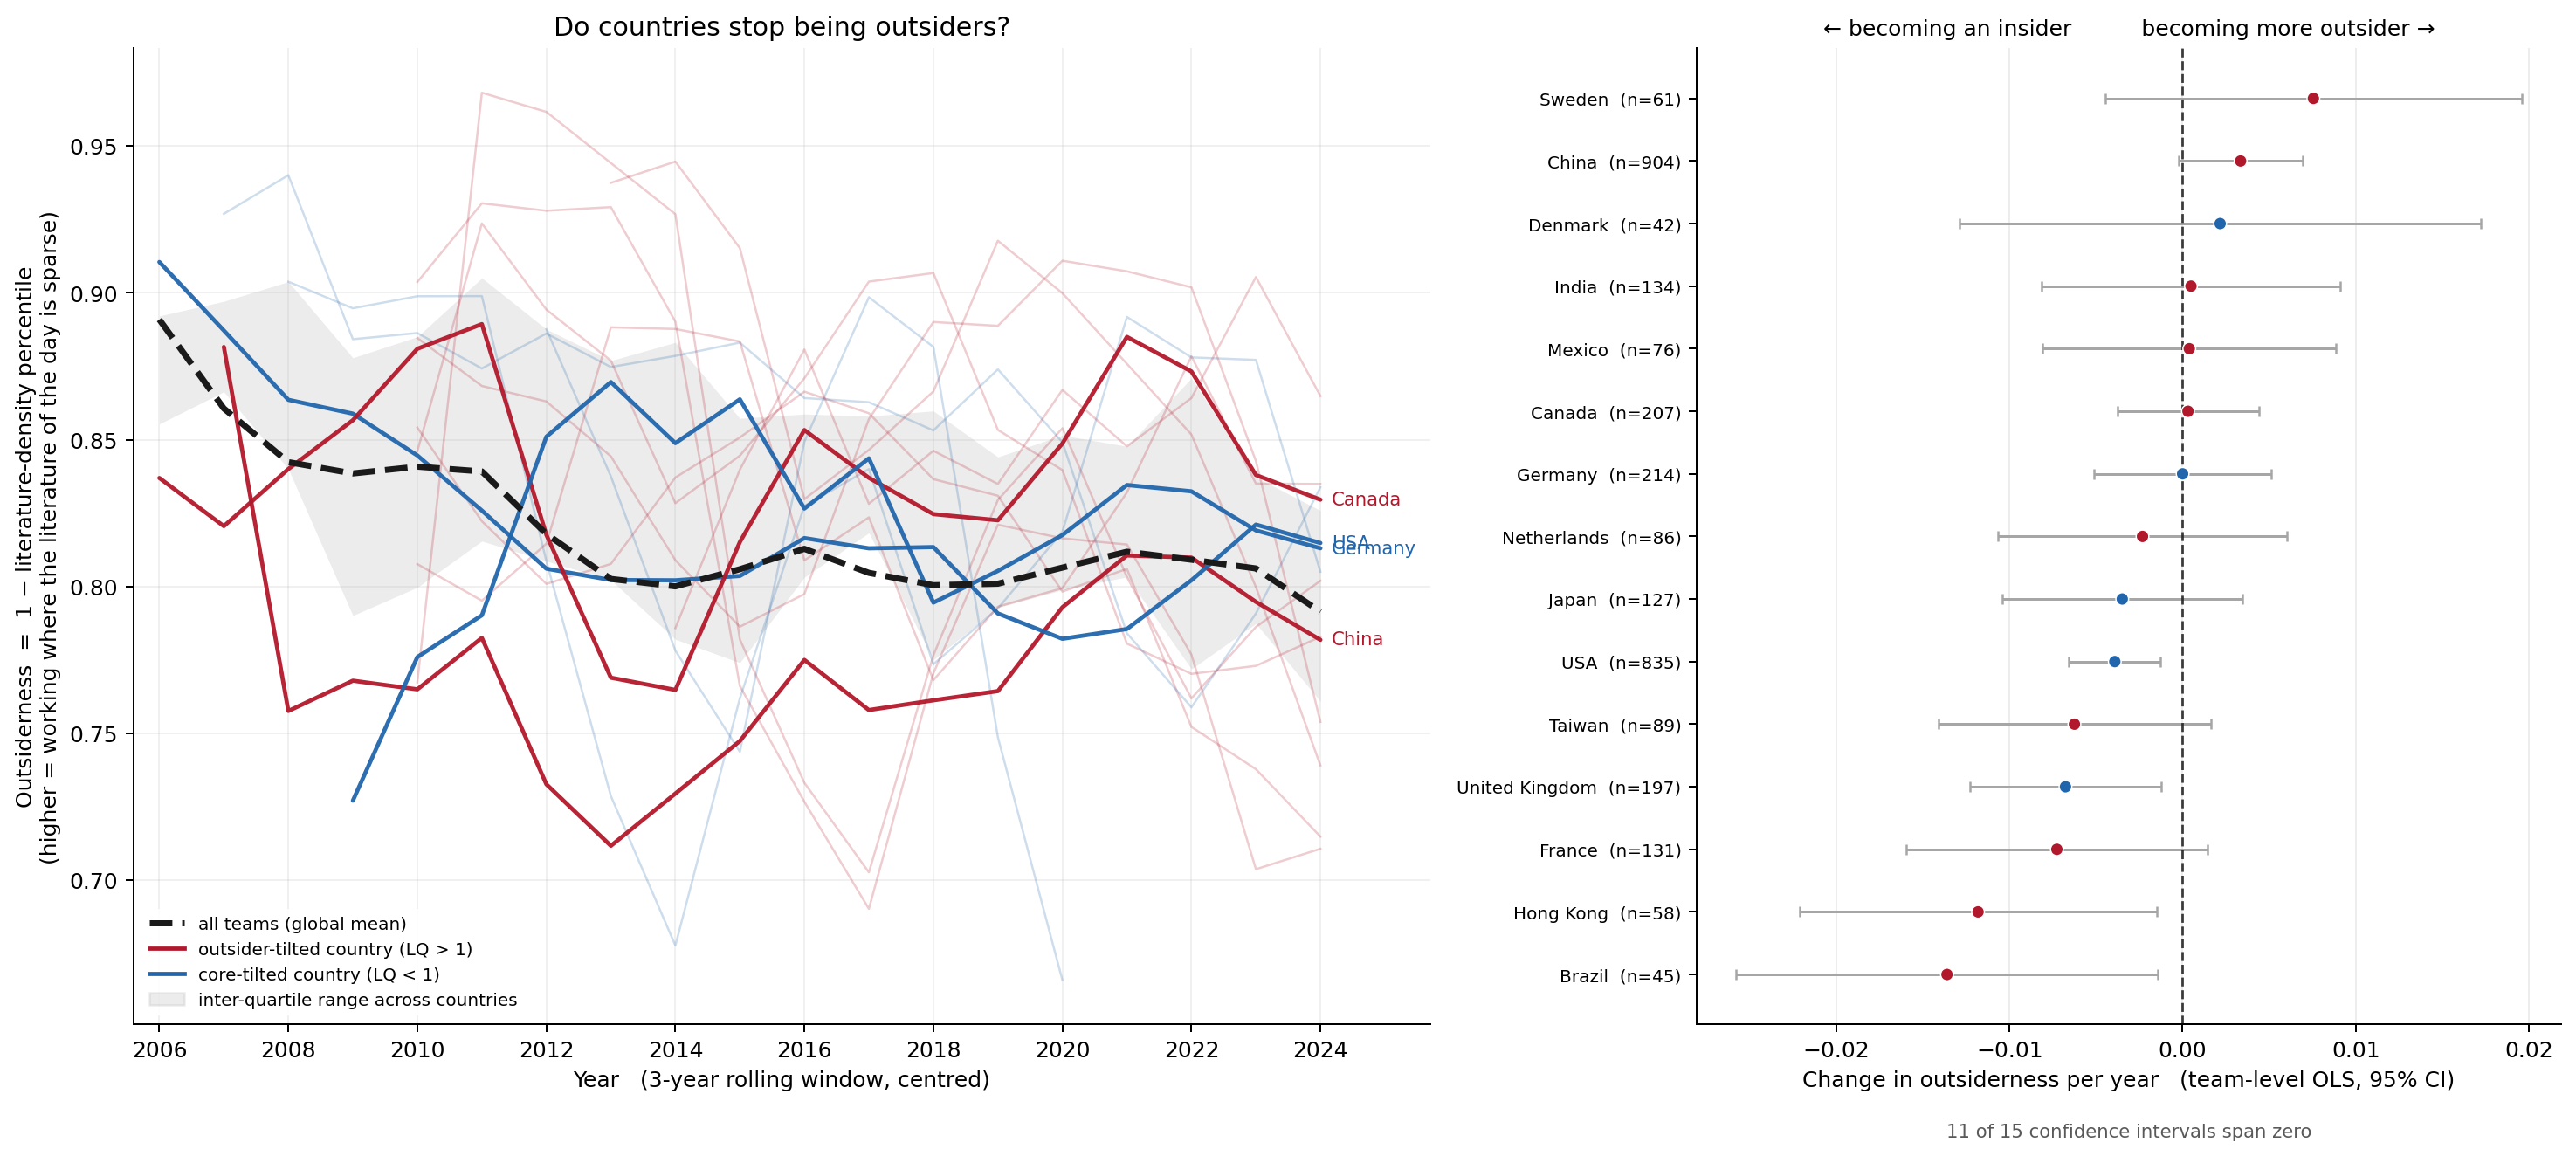

── geography_outsiderness_field_check.png


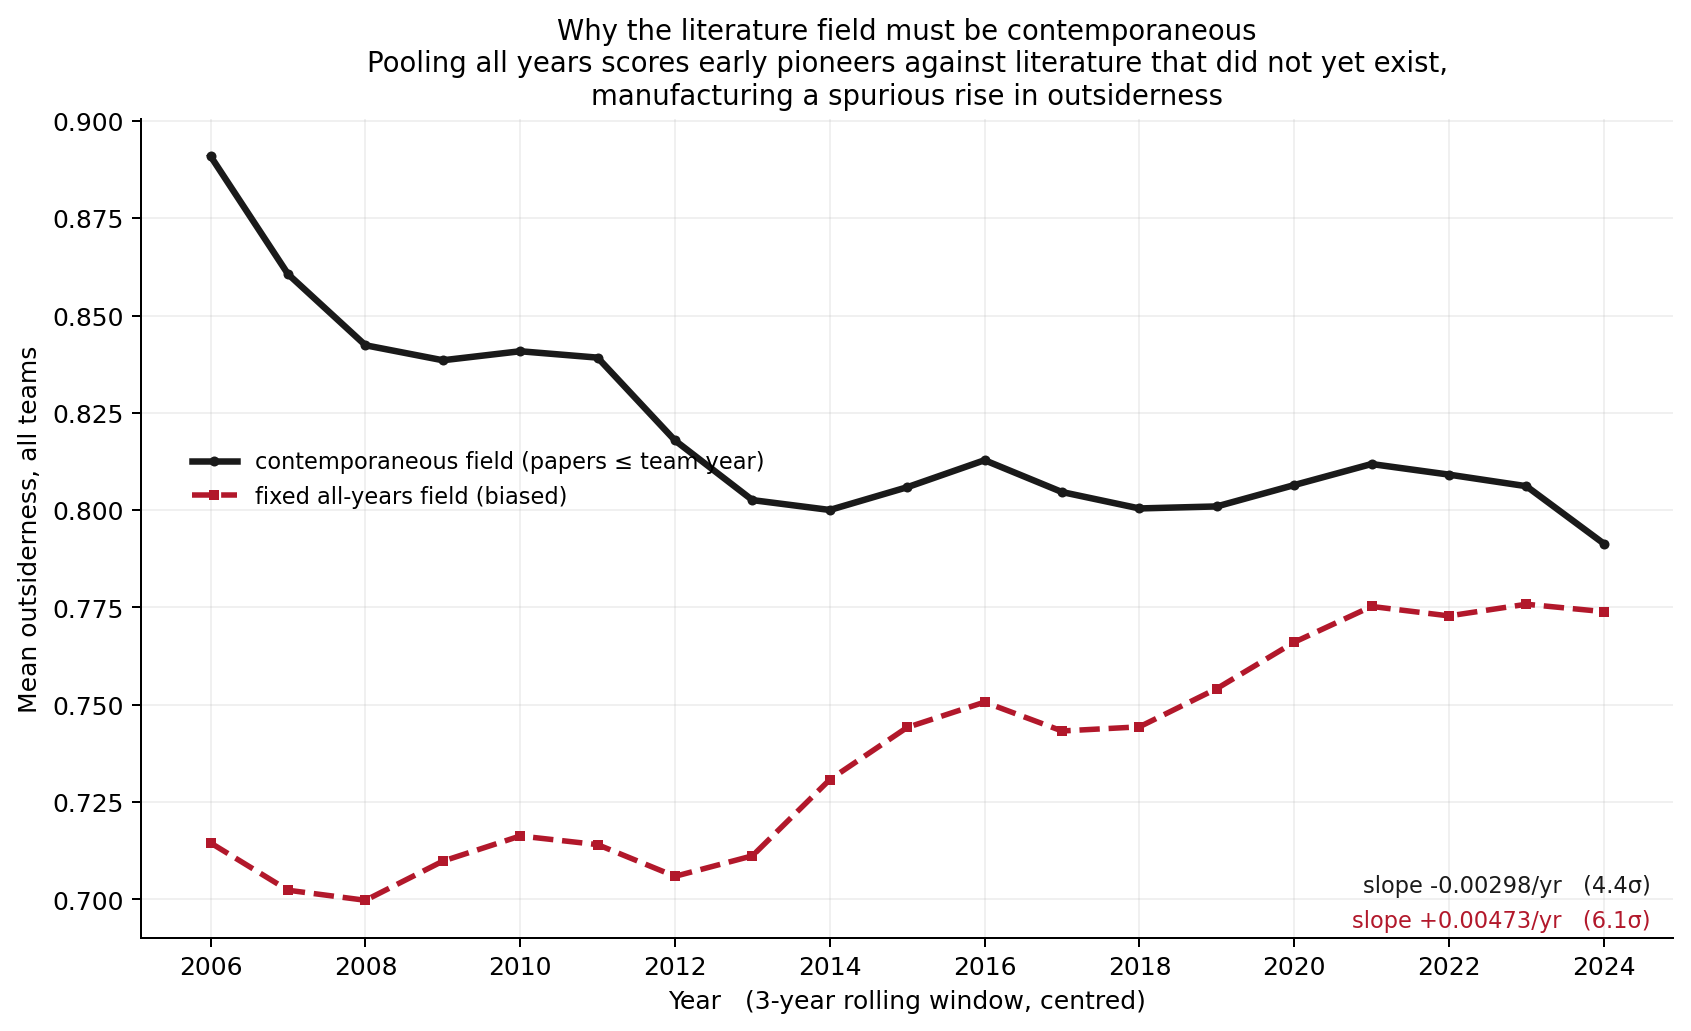

── precedence_robustness.png


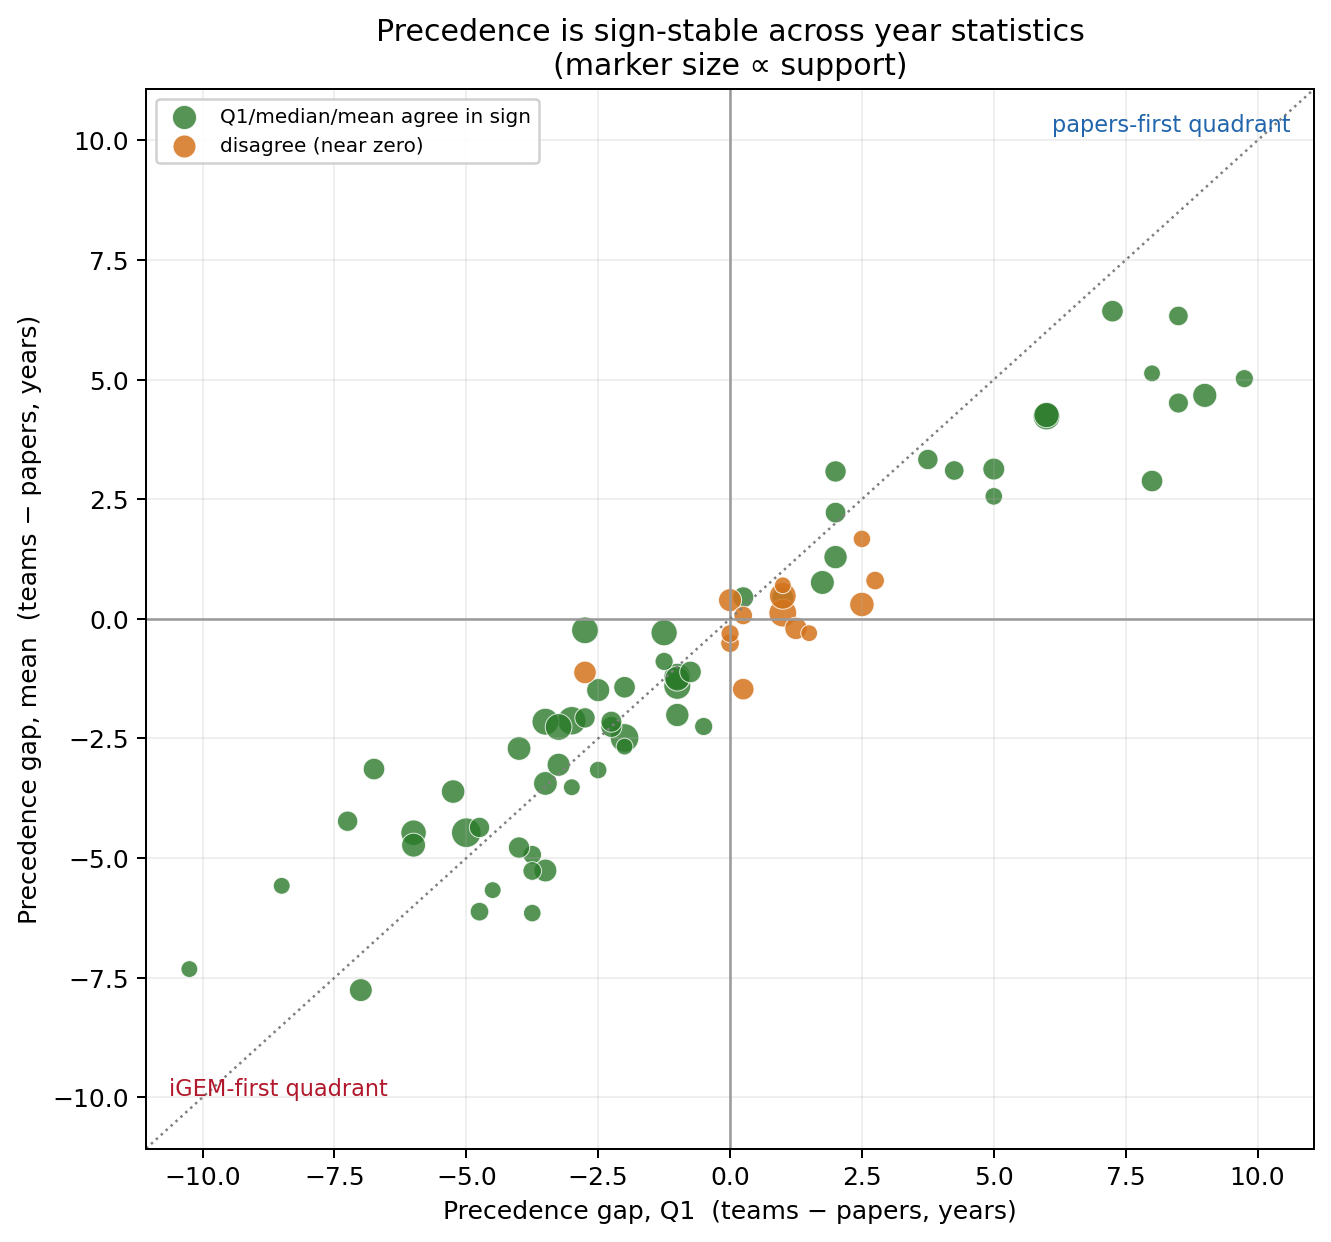

In [7]:
from IPython.display import Image, display

_figs = [
    "density_ratio_eras.png",
    "geography_lq.png",
    "geography_topic_matrix.png",
    "geography_lead_orientation.png",
    "geography_outsiderness_trajectory.png",
    "geography_outsiderness_field_check.png",
    "precedence_robustness.png",
]
for _f in _figs:
    _p = REPORTS / _f
    print(f"── {_f}" + ("" if _p.exists() else "   (MISSING)"))
    if _p.exists():
        display(Image(filename=str(_p)))